# Prueba de acceso a datos con STAC (Planetary Computer)

Notebook de prueba para evaluar el flujo STAC en el environment `1geo20`.

1. Conexión al catálogo y verificación de colecciones
2. Producto de cobertura (ESA WorldCover) sobre una área dada
3. Sentinel-2 L2A y cálculo de NDVI
4. Integración de ambos (alineación de grillas y estadística por clase)


In [ ]:
#!pip install -q rioxarray pystac-client planetary-computer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.4/72.4 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 44.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 10.5 MB/s eta 0:00:00


In [1]:
# En Colab, instalar primero: !pip install -q rioxarray pystac-client planetary-computer
import os
import numpy as np
import matplotlib.pyplot as plt
import rioxarray
import pystac_client
import planetary_computer
from rasterio.enums import Resampling

# Area de prueba (Puerto Maldonado, Madre de Dios): lon_min, lat_min, lon_max, lat_max
BBOX = [-69.30, -12.70, -69.10, -12.50]
FECHAS = "2025-07-01/2025-09-30"   # estación seca
ANIO_WC = 2021                      # año del mapa WorldCover

# Configuración de GDAL para lectura remota de COG
os.environ["GDAL_DISABLE_READDIR_ON_OPEN"] = "EMPTY_DIR"
os.environ["GDAL_HTTP_MERGE_CONSECUTIVE_RANGES"] = "YES"
os.environ["VSI_CACHE"] = "TRUE"

## Bloque 1. Conexión y colecciones

In [3]:
# Catálogo sin modificador. Los items se firman uno a uno, solo cuando se van a leer
catalogo = pystac_client.Client.open("https://planetarycomputer.microsoft.com/api/stac/v1")

ids = [c.id for c in catalogo.get_collections()]
print(len(ids), "colecciones en el catálogo")
for c in ["esa-worldcover", "sentinel-2-l2a", "landsat-c2-l2"]:
    print(c, c in ids)

138 colecciones en el catálogo
esa-worldcover True
sentinel-2-l2a True
landsat-c2-l2 True


## Bloque 2. ESA WorldCover

In [4]:
items_wc = catalogo.search(collections=["esa-worldcover"], bbox=BBOX).item_collection()
print(len(items_wc), "items")
for it in items_wc:
    print(it.id, list(it.assets))

2 items
ESA_WorldCover_10m_2021_v200_S15W072 ['map', 'input_quality', 'tilejson', 'rendered_preview']
ESA_WorldCover_10m_2020_v100_S15W072 ['map', 'input_quality', 'tilejson', 'rendered_preview']


In [5]:
%%time
item_wc = [it for it in items_wc if str(ANIO_WC) in it.id]
assert item_wc, "Ningún id contiene el año indicado; revisa la salida de la celda anterior"
item_wc = planetary_computer.sign(item_wc[0])

wc = (
    rioxarray.open_rasterio(item_wc.assets["map"].href)
    .squeeze("band", drop=True)
    .rio.clip_box(*BBOX)
    .load()
)
print(wc.rio.crs, wc.rio.resolution(), wc.shape)

EPSG:4326 (8.333333333333452e-05, -8.333333333333337e-05) (2400, 2401)
CPU times: user 81.3 ms, sys: 23.3 ms, total: 105 ms
Wall time: 1.68 s


 10  Árboles               75.8 %
 20  Arbustos               0.1 %
 30  Pastizal              14.5 %
 40  Cultivos               0.2 %
 50  Urbano                 2.9 %
 60  Suelo desnudo/ralo     0.2 %
 80  Agua                   6.1 %
 90  Humedal herbáceo       0.3 %


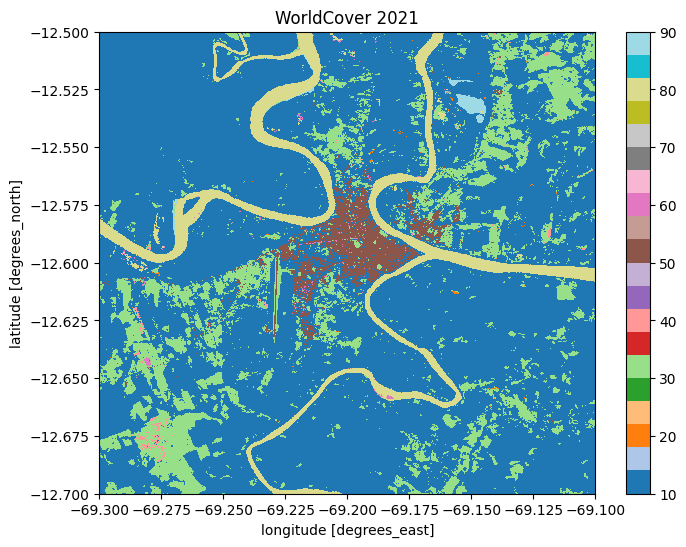

In [6]:
CLASES = {
    10: "Árboles", 20: "Arbustos", 30: "Pastizal", 40: "Cultivos", 50: "Urbano",
    60: "Suelo desnudo/ralo", 70: "Nieve/hielo", 80: "Agua", 90: "Humedal herbáceo",
    95: "Manglar", 100: "Musgo/líquenes",
}

codigos, cuentas = np.unique(wc.values, return_counts=True)
for cod, k in zip(codigos, cuentas):
    print(f"{cod:>3}  {CLASES.get(int(cod), '?'):<20} {100 * k / cuentas.sum():5.1f} %")

wc.plot(cmap="tab20", figsize=(8, 6))
plt.title(f"WorldCover {ANIO_WC}")
plt.show()

## Bloque 3. Sentinel-2 L2A y NDVI

In [7]:
busqueda = catalogo.search(
    collections=["sentinel-2-l2a"],
    bbox=BBOX,
    datetime=FECHAS,
    query={"eo:cloud_cover": {"lt": 20}},
)
items_s2 = busqueda.item_collection()
print(len(items_s2), "escenas")

# escenas cuya huella cubre todo el área
cubren = [
    i for i in items_s2
    if i.bbox[0] <= BBOX[0] and i.bbox[1] <= BBOX[1]
    and i.bbox[2] >= BBOX[2] and i.bbox[3] >= BBOX[3]
]
assert cubren, "Ninguna escena cubre el área completo; ampliar FECHAS o el umbral de nubes"

escena = planetary_computer.sign(min(cubren, key=lambda i: i.properties["eo:cloud_cover"]))
print(escena.id, escena.datetime.date(), escena.properties["eo:cloud_cover"], "% nubes")
print(list(escena.assets))

27 escenas
S2A_MSIL2A_20250830T144751_R139_T19LDG_20250830T210014 2025-08-30 0.004375 % nubes
['AOT', 'B01', 'B02', 'B03', 'B04', 'B05', 'B06', 'B07', 'B08', 'B09', 'B11', 'B12', 'B8A', 'SCL', 'WVP', 'visual', 'safe-manifest', 'granule-metadata', 'inspire-metadata', 'product-metadata', 'datastrip-metadata', 'tilejson', 'rendered_preview']


In [8]:
def leer_banda(item, clave, bbox):
    """Lee un asset recortado al área y lo convierte a reflectancia (escala 0.0001 y offset segun la linea base)."""
    da = (
        rioxarray.open_rasterio(item.assets[clave].href, masked=True)
        .squeeze("band", drop=True)
        .rio.clip_box(*bbox, crs="EPSG:4326")
        .load()
    )
    linea_base = item.properties.get("s2:processing_baseline")
    assert linea_base is not None, f"Sin linea base en las propiedades del item: {list(item.properties)}"
    offset = -0.1 if float(linea_base) >= 4.0 else 0.0
    print(clave, "linea base:", linea_base, "| offset aplicado:", offset)
    return (da * 0.0001 + offset).clip(min=0)

In [9]:
%%time
rojo = leer_banda(escena, "B04", BBOX)
nir = leer_banda(escena, "B08", BBOX)
ndvi = (nir - rojo) / (nir + rojo)
print(ndvi.shape, float(ndvi.min()), float(ndvi.max()))

B04 linea base: 05.11 | offset aplicado: -0.1
B08 linea base: 05.11 | offset aplicado: -0.1
(2214, 2175) -0.49635040760040283 0.9255985021591187
CPU times: user 1.61 s, sys: 98 ms, total: 1.71 s
Wall time: 6.53 s


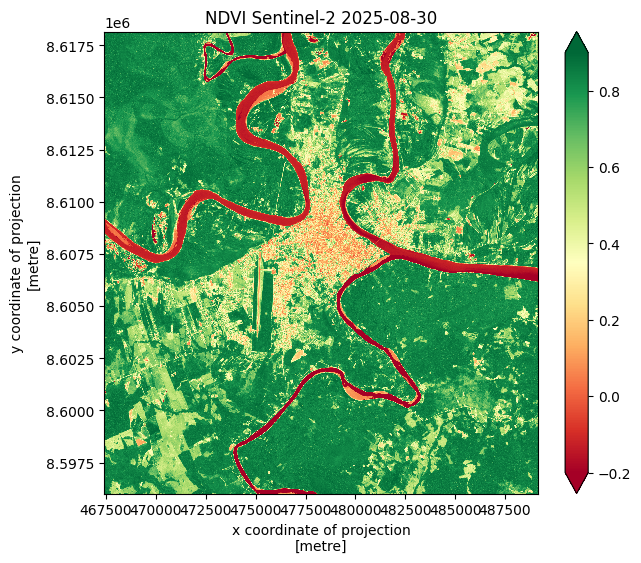

In [10]:
ndvi.plot(cmap="RdYlGn", vmin=-0.2, vmax=0.9, figsize=(7, 6))
plt.title(f"NDVI Sentinel-2 {escena.datetime.date()}")
plt.show()

In [ ]:
# Guardar los recortes para reutilizarlos sin volver a leer de la red
os.makedirs("datos_prueba", exist_ok=True)
wc.rio.to_raster("datos_prueba/worldcover_area.tif")
ndvi.rio.to_raster("datos_prueba/ndvi_area.tif")

## Bloque 4. Integración

In [11]:
# La clase es categórica, por eso el remuestreo es de vecino más cercano
wc_alineado = wc.rio.reproject_match(ndvi, resampling=Resampling.nearest)
wc_alineado = wc_alineado.where(wc_alineado.isin(list(CLASES)))

por_clase = ndvi.groupby(wc_alineado.rename("clase")).mean()
for cod, v in zip(por_clase["clase"].values, por_clase.values):
    print(f"{CLASES[int(cod)]:<20} NDVI medio {v:5.2f}")

Árboles              NDVI medio  0.77
Arbustos             NDVI medio  0.69
Pastizal             NDVI medio  0.55
Cultivos             NDVI medio  0.61
Urbano               NDVI medio  0.25
Suelo desnudo/ralo   NDVI medio  0.22
Agua                 NDVI medio -0.09
Humedal herbáceo     NDVI medio  0.58


In [12]:
wc_alineado

<xarray.DataArray (y: 2214, x: 2175)> Size: 19MB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., 10., 30., nan],
       [10., 10., 10., ..., 10., 30., nan],
       ...,
       [nan, nan, nan, ..., 10., 10., 10.],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], dtype=float32)
Coordinates:
  * y            (y) float64 18kB 8.618e+06 8.618e+06 ... 8.596e+06 8.596e+06
  * x            (x) float64 17kB 4.674e+05 4.674e+05 ... 4.891e+05 4.891e+05
    spatial_ref  int64 8B 0
Attributes: (12/18)
    algorithm_version:  V2.0.0
    copyright:          ESA WorldCover project 2021 / Contains modified Coper...
    creation_time:      2022-10-21 07:35:40.236136
    legend:             10  Tree cover\n20  Shrubland\n30  Grassland\n40  Cro...
    license:            CC-BY 4.0 - https://creativecommons.org/licenses/by/4.0/
    product_crs:        EPSG:4326
    ...                 ...
    time_start:         2021-01-01T00:00:00Z
    title:              ESA WorldCover product at 10m resolution for year 2021
    AREA_OR_POINT:      Area
    scale_factor:       1.0
    add_offset:         0.0
    _FillValue:         0

In [13]:
ndvi

<xarray.DataArray (y: 2214, x: 2175)> Size: 19MB
array([[0.84679526, 0.8289051 , 0.8212863 , ..., 0.66384774, 0.47595686,
        0.3731868 ],
       [0.8590355 , 0.84312594, 0.85106933, ..., 0.6591376 , 0.4609016 ,
        0.41530055],
       [0.8409158 , 0.8515489 , 0.84191686, ..., 0.61995006, 0.48239967,
        0.42286006],
       ...,
       [0.8679388 , 0.8672286 , 0.87815446, ..., 0.78324175, 0.8495371 ,
        0.8386096 ],
       [0.871256  , 0.8707225 , 0.8647872 , ..., 0.7897511 , 0.8373529 ,
        0.816581  ],
       [0.8586592 , 0.8634092 , 0.82906914, ..., 0.8245615 , 0.7964287 ,
        0.82725286]], dtype=float32)
Coordinates:
  * y            (y) float64 18kB 8.618e+06 8.618e+06 ... 8.596e+06 8.596e+06
  * x            (x) float64 17kB 4.674e+05 4.674e+05 ... 4.891e+05 4.891e+05
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:  Area
    scale_factor:   1.0
    add_offset:     0.0